# Diverse Dermatology Image Classification - GoogLeNet

By Jade Webb

Dataset: Diverse Dermatology Images Dataset by Stanford University https://ddi-dataset.github.io/

GoogLeNet code adapted from https://github.com/KhuyenLE-maths/Implementation-of-GoogLeNet-on-Keras/blob/main/Implementation_of_GoogLeNet_on_Keras.ipynb

Goal: classify samples of dermatology images of patients with darker skin tones as benign or malignant, to support identification of malignant lesions on people of color.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import tensorflow as tf
from tensorflow.keras import (
    datasets,
    layers,
    models,
    utils,
)
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Constants

In [3]:
IMAGE_SIZE = 224
TRAIN_SPLIT = 0.7
BATCH_SIZE = 108

## Display Funtion

In [4]:
# Displays n random images from each one of the supplied arrays.
def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

## Load Diverse Dermatology Metadata

In [33]:
# Load metadata
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DDI/ddidiversedermatologyimages/ddi_metadata.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

In [34]:
df

,DDI_ID,DDI_file,skin_tone,malignant,disease
0,1,000001.png,56,True,melanoma-in-situ
1,2,000002.png,56,True,melanoma-in-situ
2,3,000003.png,56,True,mycosis-fungoides
3,4,000004.png,56,True,squamous-cell-carcinoma-in-situ
4,5,000005.png,12,True,basal-cell-carcinoma
...,...,...,...,...,...
651,652,000652.png,34,False,pyogenic-granuloma
652,653,000653.png,34,False,melanocytic-nevi
653,654,000654.png,34,False,acral-melanotic-macule
654,655,000655.png,34,True,squamous-cell-carcinoma


In [35]:
# Get malignant labels
malignant = df['malignant']

# Map malignancy classes to numbers
unique_malignant = malignant.unique().tolist()
malignant_to_int = {malignant: i for i, malignant in enumerate(unique_malignant)}

NUM_CLASSES = len(unique_malignant)

# Create dataset from dictionary
df_dataset = tf.data.Dataset.from_tensor_slices(malignant.map(malignant_to_int).values)

## Load Diverse Dermatology Dataset Images

In [36]:
# Load images into a dataset
ddi = utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/DDI/ddidiversedermatologyimages/",
    labels=None,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=None,
    shuffle=False,
    interpolation="bilinear",
)

Found 656 files.


In [37]:
ddi

<_PrefetchDataset element_spec=TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None)>

## Visualize Dataset Sample

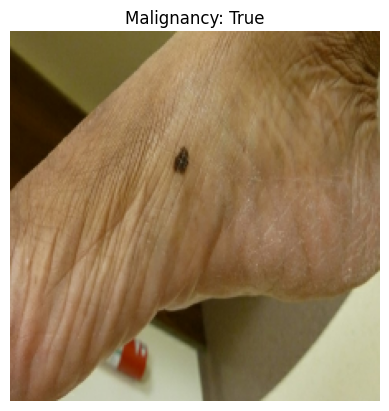

In [38]:
for row in ddi.take(1):
    plt.imshow(row.numpy().astype("uint8"))
    for label in df_dataset.take(1):
      malignant = unique_malignant[label.numpy()]
      plt.title("Malignancy: " + str(malignant))
    plt.axis("off")

## Combine Image and Label Datasets

In [39]:
dataset = tf.data.Dataset.zip((ddi, df_dataset))

## Shuffling

In [40]:
dataset = dataset.shuffle(buffer_size=dataset.cardinality(), seed=42)

## Train Validation Test Split

In [41]:
train_size = int(TRAIN_SPLIT * ddi.cardinality().numpy())
val_test_size = (ddi.cardinality().numpy() - train_size) / 2

In [42]:
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)
val_dataset = val_dataset.take(val_test_size)
test_dataset = dataset.skip(train_size)
test_dataset = test_dataset.skip(val_test_size)
test_dataset = test_dataset.take(val_test_size)

## Preprocess Images

In [43]:
# Image augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2)
])

# Preprocess images with augmentation and repeat labels for auxiliary outputs
def preprocess_and_augment(img, label):
    img = tf.cast(img, "float32") / 255.0
    img = data_augmentation(img, training=True)
    return img, (label, label, label)

# Preprocess images and repeat labels for auxiliary outputs
def preprocess(img, label):
    img = tf.cast(img, "float32") / 255.0
    return img, (label, label, label)

train_dataset = train_dataset.map(preprocess_and_augment)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

## Batching

In [44]:
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Model Definition

### Inception Block

In [50]:
def Inception_block(input_layer, f1, f2_conv1, f2_conv3, f3_conv1, f3_conv5, f4):
  # Input:
  # - f1: number of filters of the 1x1 convolutional layer in the first path
  # - f2_conv1, f2_conv3 are number of filters corresponding to the 1x1 and 3x3 convolutional layers in the second path
  # - f3_conv1, f3_conv5 are the number of filters corresponding to the 1x1 and 5x5  convolutional layer in the third path
  # - f4: number of filters of the 1x1 convolutional layer in the fourth path

  # 1st path:
  path1 = layers.Conv2D(filters=f1, kernel_size = (1,1), padding = 'same', activation = 'relu')(input_layer)

  # 2nd path
  path2 = layers.Conv2D(filters = f2_conv1, kernel_size = (1,1), padding = 'same', activation = 'relu')(input_layer)
  path2 = layers.Conv2D(filters = f2_conv3, kernel_size = (3,3), padding = 'same', activation = 'relu')(path2)

  # 3rd path
  path3 = layers.Conv2D(filters = f3_conv1, kernel_size = (1,1), padding = 'same', activation = 'relu')(input_layer)
  path3 = layers.Conv2D(filters = f3_conv5, kernel_size = (5,5), padding = 'same', activation = 'relu')(path3)

  # 4th path
  path4 = layers.MaxPooling2D((3,3), strides= (1,1), padding = 'same')(input_layer)
  path4 = layers.Conv2D(filters = f4, kernel_size = (1,1), padding = 'same', activation = 'relu')(path4)

  output_layer = layers.concatenate([path1, path2, path3, path4], axis = -1)

  return output_layer

### GoogLeNet

In [51]:
def GoogLeNet():
  # input layer
  input_layer = layers.Input(shape = (224, 224, 3))

  # convolutional layer: filters = 64, kernel_size = (7,7), strides = 2
  X = layers.Conv2D(filters = 64, kernel_size = (7,7), strides = 2, padding = 'valid', activation = 'relu')(input_layer)

  # max-pooling layer: pool_size = (3,3), strides = 2
  X = layers.MaxPooling2D(pool_size = (3,3), strides = 2)(X)

  # convolutional layer: filters = 64, strides = 1
  X = layers.Conv2D(filters = 64, kernel_size = (1,1), strides = 1, padding = 'same', activation = 'relu')(X)

  # convolutional layer: filters = 192, kernel_size = (3,3)
  X = layers.Conv2D(filters = 192, kernel_size = (3,3), padding = 'same', activation = 'relu')(X)

  # max-pooling layer: pool_size = (3,3), strides = 2
  X = layers.MaxPooling2D(pool_size= (3,3), strides = 2)(X)

  # 1st Inception block
  X = Inception_block(X, f1 = 64, f2_conv1 = 96, f2_conv3 = 128, f3_conv1 = 16, f3_conv5 = 32, f4 = 32)

  # 2nd Inception block
  X = Inception_block(X, f1 = 128, f2_conv1 = 128, f2_conv3 = 192, f3_conv1 = 32, f3_conv5 = 96, f4 = 64)

  # max-pooling layer: pool_size = (3,3), strides = 2
  X = layers.MaxPooling2D(pool_size= (3,3), strides = 2)(X)

  # 3rd Inception block
  X = Inception_block(X, f1 = 192, f2_conv1 = 96, f2_conv3 = 208, f3_conv1 = 16, f3_conv5 = 48, f4 = 64)

  # Extra network 1:
  X1 = layers.AveragePooling2D(pool_size = (5,5), strides = 3)(X)
  X1 = layers.Conv2D(filters = 128, kernel_size = (1,1), padding = 'same', activation = 'relu')(X1)
  X1 = layers.Flatten()(X1)
  X1 = layers.Dense(1024, activation = 'relu')(X1)
  X1 = layers.Dropout(0.7)(X1)
  X1 = layers.Dense(5, activation = 'softmax')(X1)


  # 4th Inception block
  X = Inception_block(X, f1 = 160, f2_conv1 = 112, f2_conv3 = 224, f3_conv1 = 24, f3_conv5 = 64, f4 = 64)

  # 5th Inception block
  X = Inception_block(X, f1 = 128, f2_conv1 = 128, f2_conv3 = 256, f3_conv1 = 24, f3_conv5 = 64, f4 = 64)

  # 6th Inception block
  X = Inception_block(X, f1 = 112, f2_conv1 = 144, f2_conv3 = 288, f3_conv1 = 32, f3_conv5 = 64, f4 = 64)

  # Extra network 2:
  X2 = layers.AveragePooling2D(pool_size = (5,5), strides = 3)(X)
  X2 = layers.Conv2D(filters = 128, kernel_size = (1,1), padding = 'same', activation = 'relu')(X2)
  X2 = layers.Flatten()(X2)
  X2 = layers.Dense(1024, activation = 'relu')(X2)
  X2 = layers.Dropout(0.7)(X2)
  X2 = layers.Dense(1000, activation = 'softmax')(X2)


  # 7th Inception block
  X = Inception_block(X, f1 = 256, f2_conv1 = 160, f2_conv3 = 320, f3_conv1 = 32,
                      f3_conv5 = 128, f4 = 128)

  # max-pooling layer: pool_size = (3,3), strides = 2
  X = layers.MaxPooling2D(pool_size = (3,3), strides = 2)(X)

  # 8th Inception block
  X = Inception_block(X, f1 = 256, f2_conv1 = 160, f2_conv3 = 320, f3_conv1 = 32, f3_conv5 = 128, f4 = 128)

  # 9th Inception block
  X = Inception_block(X, f1 = 384, f2_conv1 = 192, f2_conv3 = 384, f3_conv1 = 48, f3_conv5 = 128, f4 = 128)

  # Global Average pooling layer
  X = layers.GlobalAveragePooling2D(name = 'GAPL')(X)

  # Dropoutlayer
  X = layers.Dropout(0.4)(X)

  # output layer
  X = layers.Dense(NUM_CLASSES, activation = 'softmax')(X)

  # model
  model = models.Model(input_layer, [X, X1, X2], name = 'GoogLeNet')

  return model

### Model Architecture

In [52]:
model = GoogLeNet()

In [53]:
model.summary()

Model: "GoogLeNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_245 (Conv2D) │ (None, 109, 109,  │      9,472 │ input_layer_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_55    │ (None, 54, 54,    │          0 │ conv2d_245[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_246 (Conv2D) │ (None, 54, 54,    │      4,160 │ max_pooling2d_55… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_247 (Conv2D) │ (None, 54, 54,    │    110,784 │ conv2d_246[0][0]  │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_56    │ (None, 26, 26,    │          0 │ conv2d_247[0][0]  │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_249 (Conv2D) │ (None, 26, 26,    │     18,528 │ max_pooling2d_56… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_251 (Conv2D) │ (None, 26, 26,    │      3,088 │ max_pooling2d_56… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_57    │ (None, 26, 26,    │          0 │ max_pooling2d_56… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_248 (Conv2D) │ (None, 26, 26,    │     12,352 │ max_pooling2d_56… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_250 (Conv2D) │ (None, 26, 26,    │    110,720 │ conv2d_249[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_252 (Conv2D) │ (None, 26, 26,    │     12,832 │ conv2d_251[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_253 (Conv2D) │ (None, 26, 26,    │      6,176 │ max_pooling2d_57… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 26, 26,    │          0 │ conv2d_248[0][0], │
│ (Concatenate)       │ 256)              │            │ conv2d_250[0][0], │
│                     │                   │            │ conv2d_252[0][0], │
│                     │                   │            │ conv2d_253[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_255 (Conv2D) │ (None, 26, 26,    │     32,896 │ concatenate_36[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_257 (Conv2D) │ (None, 26, 26,    │      8,224 │ concatenate_36[0… │
│                     │ 32)               │            │                 

 Total params: 9,500,447 (36.24 MB)

 Trainable params: 9,500,447 (36.24 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [54]:
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss=[tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)],
              metrics=['accuracy', 'accuracy', 'accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(train_dataset, epochs=50,
                    validation_data=(val_dataset), callbacks=[early_stopping])

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 134s 9s/step - dense_21_accuracy: 0.4805 - dense_21_loss: 1.3779 - dense_23_accuracy: 0.4048 - dense_23_loss: 6.1887 - dense_24_accuracy: 0.5025 - dense_24_loss: 1.5230 - loss: 9.4519 - val_dense_21_accuracy: 0.3265 - val_dense_21_loss: 0.9143 - val_dense_23_accuracy: 0.6735 - val_dense_23_loss: 3.6678 - val_dense_24_accuracy: 0.6735 - val_dense_24_loss: 0.6699 - val_loss: 5.2520
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - dense_21_accuracy: 0.2680 - dense_21_loss: 0.9691 - dense_23_accuracy: 0.4491 - dense_23_loss: 3.6499 - dense_24_accuracy: 0.7586 - dense_24_loss: 0.6482 - loss: 5.3196 - val_dense_21_accuracy: 0.7959 - val_dense_21_loss: 0.6550 - val_dense_23_accuracy: 0.2041 - val_dense_23_loss: 2.3782 - val_dense_24_accuracy: 0.7959 - val_dense_24_loss: 0.5080 - val_loss: 3.5412
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - dense_21_accuracy: 0.6819 - dense_21_loss: 0.6537 - dense_23_accuracy: 0.3955 - dense_23_loss: 1.4860 - dense_24_accuracy: 0

## Visualize Performance

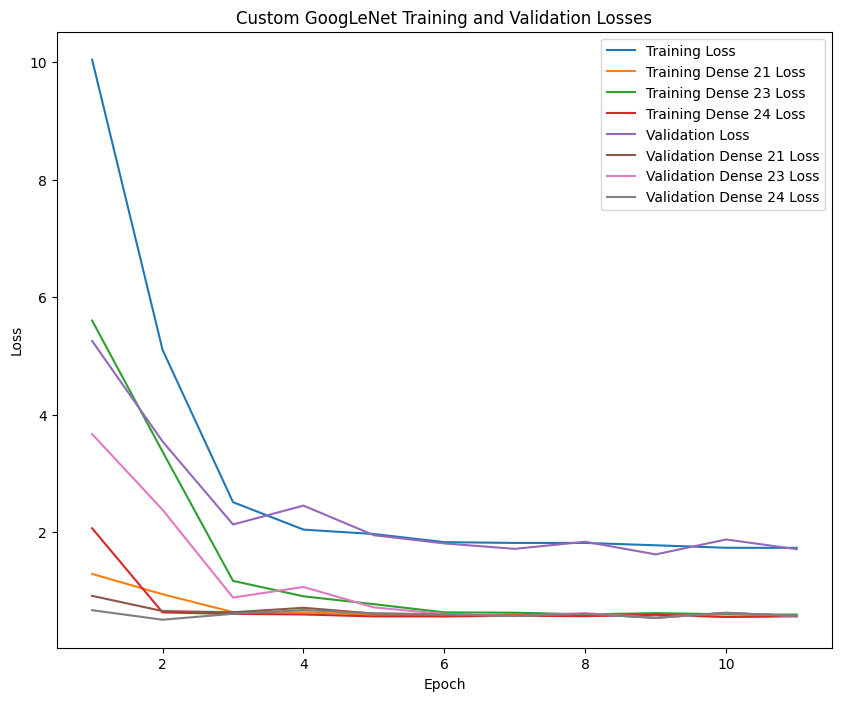

In [69]:
# Plot losses over time
losses = history.history['loss']
d_21_losses = history.history['dense_21_loss']
d_23_losses = history.history['dense_23_loss']
d_24_losses = history.history['dense_24_loss']
val_losses = history.history['val_loss']
val_d_21_losses = history.history['val_dense_21_loss']
val_d_23_losses = history.history['val_dense_23_loss']
val_d_24_losses = history.history['val_dense_24_loss']
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(np.arange(1, len(losses) + 1), losses, label="Training Loss")
ax.plot(np.arange(1, len(d_21_losses) + 1), d_21_losses, label="Training Dense 21 Loss")
ax.plot(np.arange(1, len(d_23_losses) + 1), d_23_losses, label="Training Dense 23 Loss")
ax.plot(np.arange(1, len(d_24_losses) + 1), d_24_losses, label="Training Dense 24 Loss")
ax.plot(np.arange(1, len(val_losses) + 1), val_losses, label="Validation Loss")
ax.plot(np.arange(1, len(val_d_21_losses) + 1), val_d_21_losses, label="Validation Dense 21 Loss")
ax.plot(np.arange(1, len(val_d_23_losses) + 1), val_d_23_losses, label="Validation Dense 23 Loss")
ax.plot(np.arange(1, len(val_d_24_losses) + 1), val_d_24_losses, label="Validation Dense 24 Loss")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Custom GoogLeNet Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

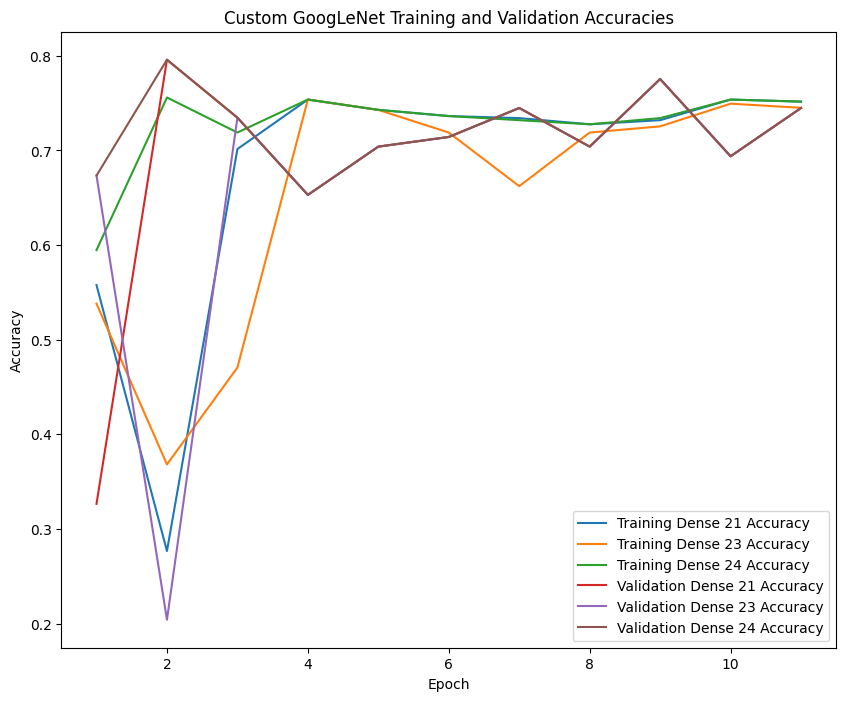

In [70]:
# Plot accuracies over time
d_21_accuracies = history.history['dense_21_accuracy']
d_23_accuracies = history.history['dense_23_accuracy']
d_24_accuracies = history.history['dense_24_accuracy']
val_d_21_accuracies = history.history['val_dense_21_accuracy']
val_d_23_accuracies = history.history['val_dense_23_accuracy']
val_d_24_accuracies = history.history['val_dense_24_accuracy']
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(np.arange(1, len(d_21_accuracies) + 1), d_21_accuracies, label="Training Dense 21 Accuracy")
ax.plot(np.arange(1, len(d_23_accuracies) + 1), d_23_accuracies, label="Training Dense 23 Accuracy")
ax.plot(np.arange(1, len(d_24_accuracies) + 1), d_24_accuracies, label="Training Dense 24 Accuracy")
ax.plot(np.arange(1, len(val_d_21_accuracies) + 1), val_d_21_accuracies, label="Validation Dense 21 Accuracy")
ax.plot(np.arange(1, len(val_d_23_accuracies) + 1), val_d_23_accuracies, label="Validation Dense 23 Accuracy")
ax.plot(np.arange(1, len(val_d_24_accuracies) + 1), val_d_24_accuracies, label="Validation Dense 24 Accuracy")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Custom GoogLeNet Training and Validation Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Model Testing

In [58]:
# Classify test set
test_dense_21_accuracy, test_dense_21_loss, test_dense_23_accuracy, test_dense_23_loss, test_dense_24_accuracy, test_dense_24_loss, test_loss = model.evaluate(test_dataset, verbose=2)

1/1 - 2s - 2s/step - dense_21_accuracy: 0.8163 - dense_21_loss: 0.4963 - dense_23_accuracy: 0.8163 - dense_23_loss: 0.4932 - dense_24_accuracy: 0.8163 - dense_24_loss: 0.4961 - loss: 1.4856
